## Importing the dataset

In [111]:
# import the necessary libraries

import torch
import torchaudio
import torchaudio.transforms as T_audio
import torchaudio.functional as F_audio
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

import random

In [112]:
!pip install --upgrade huggingface_hub

In [113]:
!pip install datasets['audio']
from datasets import load_dataset
from sklearn.model_selection import train_test_split

#load dataset
dataset = load_dataset("AbstractTTS/IEMOCAP")

In [114]:
# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Move batch to device
def to_device(data, device):
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

# Wrap a dataloader to automatically transfer data to device
class DeviceDataLoader:
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        for batch in self.dl:
            yield to_device(batch, self.device)

    def __len__(self):
      return len(self.dl)

Using device: cuda


In [115]:
#shape of the dataset
dataset.shape

{'train': (10039, 22)}

In [116]:
# Step 1: Split into train and test (80/20 split)
train_test = dataset['train'].train_test_split(test_size=0.2, seed=42)

# Step 2: Further split the training set into train and validation (e.g., 90/10 split)
train_valid = train_test['train'].train_test_split(test_size=0.1, seed=42)

# Final splits
train_dataset = train_valid['train']
valid_dataset = train_valid['test']
test_dataset = train_test['test']


In [117]:
#checking whether the classes are balanced
Counter(train_dataset['major_emotion'])

Counter({'happy': 472,
         'frustrated': 2110,
         'neutral': 1260,
         'excited': 1402,
         'surprise': 72,
         'fear': 71,
         'sad': 924,
         'angry': 893,
         'other': 22,
         'disgust': 1})

- Here we can keep 6 main emotions that seem to have a decent amount for the model to train and learn from. We drop the "Surprise", "fear", "disgust" and "other" classes.

In [118]:
print("Training Data Set shape:", train_dataset.shape)
print("Validation Data Set shape:", valid_dataset.shape)
print("Test Data Set shape:", test_dataset.shape)

Training Data Set shape: (7227, 22)
Validation Data Set shape: (804, 22)
Test Data Set shape: (2008, 22)


## Spectogram Extraction

In [119]:
import torchaudio
import torchaudio.transforms as T

import os
import torch
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset

# class CleanLogMelDataset(Dataset):
#     def __init__(self, data, label2id, merge_map,
#                  is_training=True,
#                  sample_rate=16000,
#                  max_frames=61,
#                  n_fft=1024,
#                  hop_length=256,
#                  win_length=1024,
#                  n_mels=128):

#         # Filter out entries with unsupported emotions
#         self.data = [item for item in data if item['major_emotion'] in merge_map]
#         self.label2id = label2id
#         self.merge_map = merge_map
#         self.is_training = is_training
#         self.sample_rate = sample_rate
#         self.max_frames = max_frames

#         # Log-Mel spectrogram transform
#         self.mel_transform = T.MelSpectrogram(
#             sample_rate=sample_rate,
#             n_fft=n_fft,
#             hop_length=hop_length,
#             win_length=win_length,
#             n_mels=n_mels
#         )
#         self.db_transform = T.AmplitudeToDB(top_db=80)

#         # SpecAugment (only during training)
#         self.freq_mask = T.FrequencyMasking(freq_mask_param=8)
#         self.time_mask = T.TimeMasking(time_mask_param=20)

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         entry = self.data[idx]

#         # ================================
#         # Load waveform
#         waveform = torch.tensor(entry['audio']['array']).unsqueeze(0).float()
#         orig_sr = entry['audio']['sampling_rate']

#         # ================================
#         # Resample if needed
#         if orig_sr != self.sample_rate:
#             waveform = torchaudio.transforms.Resample(
#                 orig_freq=orig_sr,
#                 new_freq=self.sample_rate
#             )(waveform)

#         # ================================
#         # Convert stereo to mono
#         if waveform.shape[0] > 1:
#             waveform = waveform.mean(dim=0, keepdim=True)

#         # ================================
#         # Pad short waveforms (less than 512 samples)
#         if waveform.shape[1] < 512:
#             pad_amt = 512 - waveform.shape[1]
#             waveform = torch.nn.functional.pad(waveform, (0, pad_amt))

#         # ================================
#         # Compute log-mel spectrogram
#         mel = self.db_transform(self.mel_transform(waveform))  # shape: [1, n_mels, T]

#         # Normalize
#         mel = (mel - mel.mean()) / (mel.std() + 1e-5)

#         # ================================
#         # Fix time axis to max_frames
#         T_ = mel.shape[-1]
#         if T_ < self.max_frames:
#             pad = torch.zeros((mel.shape[0], mel.shape[1], self.max_frames - T_))
#             mel = torch.cat((mel, pad), dim=-1)
#         elif T_ > self.max_frames:
#             mel = mel[:, :, :self.max_frames]

#         # Add batch dim if needed
#         mel = mel.unsqueeze(0).squeeze(0)  # final shape: [1, 128, max_frames]

#         # ================================
#         # Apply SpecAugment (only in training)
#         if self.is_training:
#             mel = self.freq_mask(mel)
#             mel = self.time_mask(mel)

#         # ================================
#         # Map label
#         label_str = entry['major_emotion']
#         label = self.label2id[self.merge_map[label_str]]

#         return mel, label





In [120]:
class Wav2Vec2Dataset(Dataset):
    def __init__(self, data, labelid, merge_map,
                 is_training=True,
                 sample_rate=16000,  # wav2vec2 requires 16kHz
                 max_length=160000):  # 10 seconds max at 16kHz

        # Filter out entries with unsupported emotions
        self.data = [item for item in data if item['major_emotion'] in merge_map]
        self.labelid = labelid
        self.merge_map = merge_map
        self.is_training = is_training
        self.sample_rate = sample_rate
        self.max_length = max_length

        # SpecAugment for raw waveforms during training
        # Used selectively based on research for SER
        self.augmentation = torchaudio.transforms.Vol(gain=0.5) if is_training else None

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        entry = self.data[idx]

        # ==========================
        # Load waveform
        waveform = torch.tensor(entry['audio']['array']).unsqueeze(0).float()
        orig_sr = entry['audio']['sampling_rate']

        # ==========================
        # Resample if needed
        if orig_sr != self.sample_rate:
            waveform = torchaudio.transforms.Resample(
                orig_freq=orig_sr,
                new_freq=self.sample_rate
            )(waveform)

        # ==========================
        # Convert stereo to mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # ==========================
        # Handle length consistency
        if waveform.shape[1] > self.max_length:
            # For longer utterances: randomly select a segment during training,
            # take the middle segment during evaluation
            if self.is_training:
                start = torch.randint(0, waveform.shape[1] - self.max_length + 1, (1,)).item()
                waveform = waveform[:, start:start + self.max_length]
            else:
                start = (waveform.shape[1] - self.max_length) // 2
                waveform = waveform[:, start:start + self.max_length]
        else:
            # For shorter utterances: pad with zeros
            pad_amt = self.max_length - waveform.shape[1]
            waveform = F.pad(waveform, (0, pad_amt))

        # ==========================
        # Apply data augmentation during training
        if self.is_training and self.augmentation is not None and torch.rand(1).item() < 0.5:
            waveform = self.augmentation(waveform)

        # ==========================
        # Map label
        label_str = entry['major_emotion']
        label = self.labelid[self.merge_map[label_str]]

        return waveform, label

### Creating Label Mapping

In [121]:
def create_label_mapping(dataset):
    # Keep only the classes we're currently interested in
    merge_map = {
        'happy': 'happy',
        'neutral': 'neutral',
        'sad': 'sad',
        'angry':'angry'
    }

    # Final list of target emotions
    allowed_emotions = sorted(list(set(merge_map.values())))
    label2id = {emotion: idx for idx, emotion in enumerate(allowed_emotions)}

    return label2id, merge_map


## CNN Model

In [122]:
# class EmotionCNN(nn.Module):
#     def __init__(self, num_classes):
#         super(EmotionCNN, self).__init__()
#         self.base_model = models.resnet18(pretrained=True)
#         self.base_model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
#         self.features = nn.Sequential(*list(self.base_model.children())[:-1])
#         self.dropout = nn.Dropout(0.7)
#         self.fc = nn.Linear(self.base_model.fc.in_features, num_classes)

#     def forward(self, x):
#         x = self.features(x)
#         x = torch.flatten(x, 1)
#         x = self.dropout(x)
#         x = self.fc(x)
#         return x


In [123]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class CRNNEmotion(nn.Module):
#     def __init__(self, num_classes):
#         super(CRNNEmotion, self).__init__()

#         # CNN backbone
#         self.conv_layers = nn.Sequential(
#             nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # (B, 32, 128, 61)
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d((2, 2)),  # (B, 32, 64, 30)
#             nn.Dropout(0.3),

#             nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),  # (B, 64, 64, 30)
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d((2, 2)),  # (B, 64, 32, 15)
#             nn.Dropout(0.3)
#         )

#         # GRU for temporal modeling
#         self.gru = nn.GRU(
#             input_size=64 * 32,  # Flattened frequency × channel
#             hidden_size=128,
#             batch_first=True,
#             bidirectional=True
#         )

#         # Classifier
#         self.dropout = nn.Dropout(0.3)
#         self.fc = nn.Linear(256, num_classes)  # 128 × 2 (bidirectional)

#     def forward(self, x):
#         # Input: x → [B, 1, 128, 61]
#         x = self.conv_layers(x)                # → [B, 64, 32, 15]

#         # Prepare for GRU: [B, C, F, T] → [B, T, C × F]
#         x = x.permute(0, 3, 1, 2)              # → [B, 15, 64, 32]
#         x = x.contiguous().view(x.size(0), x.size(1), -1)  # → [B, 15, 2048]

#         # GRU: temporal modeling
#         out, _ = self.gru(x)                   # → [B, 15, 256]
#         out = out[:, -1, :]                    # Last timestep → [B, 256]

#         out = self.dropout(out)
#         out = self.fc(out)                     # → [B, num_classes]
#         return out


In [124]:
# class TransformerSERModel(nn.Module):
#     def __init__(self, num_classes, cnn_pattern='expansion', d_model=256, nhead=8,
#                  num_encoder_layers=3, dim_feedforward=1024, dropout=0.3):
#         super(TransformerSERModel, self).__init__()

#         # CNN Feature Extractor (keeping the best pattern from our experiments)
#         if cnn_pattern == 'expansion':
#             # Expansion pattern: 64→128→256
#             self.conv_layers = nn.Sequential(
#                 nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(64),
#                 nn.ReLU(),
#                 nn.MaxPool2d((2, 2)),
#                 nn.Dropout(dropout),

#                 nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(128),
#                 nn.ReLU(),
#                 nn.Dropout(dropout),

#                 nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(256),
#                 nn.ReLU(),
#                 nn.MaxPool2d((2, 2)),
#                 nn.Dropout(dropout)
#             )
#             cnn_output_channels = 256

#         # Linear projection to transformer dimension
#         self.projection = nn.Linear(cnn_output_channels * 32, d_model)

#         # Positional encoding (important for transformer)
#         self.pos_encoder = PositionalEncoding(d_model, dropout)

#         # Transformer encoder
#         encoder_layers = nn.TransformerEncoderLayer(
#             d_model=d_model,
#             nhead=nhead,
#             dim_feedforward=dim_feedforward,
#             dropout=dropout,
#             batch_first=True
#         )
#         self.transformer_encoder = nn.TransformerEncoder(
#             encoder_layers,
#             num_layers=num_encoder_layers
#         )

#         # Final classifier
#         self.classifier = nn.Linear(d_model, num_classes)

#     def forward(self, mel):
#         # Handle extra dimension if present
#         if mel.dim() == 5:
#             mel = mel.squeeze(1)

#         # CNN feature extraction
#         x = self.conv_layers(mel)  # [B, 256, 32, 15]

#         # Reshape for transformer: [B, C, F, T] -> [B, T, C*F]
#         x = x.permute(0, 3, 1, 2)  # [B, 15, 256, 32]
#         x = x.contiguous().view(x.size(0), x.size(1), -1)  # [B, 15, 8192]

#         # Project to transformer dimension
#         x = self.projection(x)  # [B, 15, d_model]

#         # Add positional encoding
#         x = self.pos_encoder(x)

#         # Transformer encoding
#         x = self.transformer_encoder(x)  # [B, 15, d_model]

#         # Global pooling (mean of sequence)
#         x = torch.mean(x, dim=1)  # [B, d_model]

#         # Classification
#         x = self.classifier(x)  # [B, num_classes]

#         return x

# # Positional encoding for transformer
# class PositionalEncoding(nn.Module):
#     def __init__(self, d_model, dropout=0.1, max_len=5000):
#         super(PositionalEncoding, self).__init__()
#         self.dropout = nn.Dropout(p=dropout)

#         # Compute positional encodings
#         position = torch.arange(max_len).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
#         pe = torch.zeros(max_len, d_model)
#         pe[:, 0::2] = torch.sin(position * div_term)
#         pe[:, 1::2] = torch.cos(position * div_term)
#         pe = pe.unsqueeze(0)

#         # Register buffer (not a parameter, but part of the module)
#         self.register_buffer('pe', pe)

#     def forward(self, x):
#         x = x + self.pe[:, :x.size(1), :]
#         return self.dropout(x)

In [125]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np

# class SelfAttentionModule(nn.Module):
#     def __init__(self, hidden_dim):
#         super(SelfAttentionModule, self).__init__()
#         # Query, key, and value projections
#         self.query = nn.Linear(hidden_dim, hidden_dim // 4)
#         self.key = nn.Linear(hidden_dim, hidden_dim // 4)
#         self.value = nn.Linear(hidden_dim, hidden_dim)

#         # Scaling factor for dot product attention
#         self.scale = np.sqrt(hidden_dim // 4)

#     def forward(self, x):
#         # x shape: [batch_size, seq_len, hidden_dim]
#         batch_size = x.size(0)

#         # Create query, key, value projections
#         q = self.query(x)  # [batch_size, seq_len, hidden_dim//4]
#         k = self.key(x)    # [batch_size, seq_len, hidden_dim//4]
#         v = self.value(x)  # [batch_size, seq_len, hidden_dim]

#         # Calculate attention scores
#         attention = torch.bmm(q, k.transpose(1, 2)) / self.scale
#         attention = F.softmax(attention, dim=2)

#         # Apply attention to value vectors
#         context = torch.bmm(attention, v)

#         # Calculate attention weights across sequence dimension
#         seq_weights = F.softmax(torch.sum(attention, dim=2), dim=1).unsqueeze(2)

#         # Apply sequence-level attention to get a single vector per sample
#         out = torch.sum(context * seq_weights, dim=1)

#         return out

# class CNNAttentionEmotion(nn.Module):
#     def __init__(self, num_classes, cnn_pattern='original'):
#         super(CNNAttentionEmotion, self).__init__()

#         # Define CNN backbone based on pattern
#         if cnn_pattern == 'reducing':
#             # Reducing pattern: 256→128
#             self.conv_layers = nn.Sequential(
#                 nn.Conv2d(1, 256, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(256),
#                 nn.ReLU(),
#                 nn.MaxPool2d((2, 2)),
#                 nn.Dropout(0.3),

#                 nn.Conv2d(256, 128, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(128),
#                 nn.ReLU(),
#                 nn.MaxPool2d((2, 2)),
#                 nn.Dropout(0.3)
#             )
#             cnn_output_channels = 128

#         elif cnn_pattern == 'bottleneck':
#             # Bottleneck pattern: 128→64→128
#             self.conv_layers = nn.Sequential(
#                 nn.Conv2d(1, 128, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(128),
#                 nn.ReLU(),
#                 nn.MaxPool2d((2, 2)),
#                 nn.Dropout(0.3),

#                 nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(64),
#                 nn.ReLU(),
#                 nn.Dropout(0.3),

#                 nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
#                 nn.BatchNorm2d(128),
#                 nn.ReLU(),
#                 nn.MaxPool2d((2, 2)),
#                 nn.Dropout(0.3)
#             )
#             cnn_output_channels = 128

    #     elif cnn_pattern == 'expansion':
    #         # Expansion pattern: 64→128→256
    #         self.conv_layers = nn.Sequential(
    #             nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(64),
    #             nn.ReLU(),
    #             nn.MaxPool2d((2, 2)),
    #             nn.Dropout(0.3),

    #             nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(128),
    #             nn.ReLU(),
    #             nn.Dropout(0.3),

    #             nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(256),
    #             nn.ReLU(),
    #             nn.MaxPool2d((2, 2)),
    #             nn.Dropout(0.3)
    #         )
    #         cnn_output_channels = 256

    #     elif cnn_pattern == 'constant':
    #         # Constant width pattern: 64→64→64→64→64
    #         self.conv_layers = nn.Sequential(
    #             nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(64),
    #             nn.ReLU(),
    #             nn.MaxPool2d((2, 2)),
    #             nn.Dropout(0.3),

    #             nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(64),
    #             nn.ReLU(),
    #             nn.Dropout(0.3),

    #             nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(64),
    #             nn.ReLU(),
    #             nn.Dropout(0.3),

    #             nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(64),
    #             nn.ReLU(),
    #             nn.Dropout(0.3),

    #             nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
    #             nn.BatchNorm2d(64),
    #             nn.ReLU(),
    #             nn.MaxPool2d((2, 2)),
    #             nn.Dropout(0.3)
    #         )
    #         cnn_output_channels = 64

    #     # GRU for temporal modeling
    #     self.gru = nn.GRU(
    #         input_size=cnn_output_channels * 32,  # Adjust based on CNN output
    #         hidden_size=128,
    #         batch_first=True,
    #         bidirectional=True
    #     )

    #     # Self-attention module
    #     self.attention = SelfAttentionModule(hidden_dim=256)  # 256 = 128*2 (bidirectional)

    #     # Classifier
    #     self.dropout = nn.Dropout(0.3)
    #     self.fc = nn.Linear(256, num_classes)

    # def forward(self, mel):
    #     # Handle extra dimension if present
    #     if mel.dim() == 5:
    #         mel = mel.squeeze(1)

    #     # Process spectrogram with CNN
    #     x = self.conv_layers(mel)

    #     # Prepare for GRU: [B, C, F, T] -> [B, T, C * F]
    #     x = x.permute(0, 3, 1, 2)
    #     x = x.contiguous().view(x.size(0), x.size(1), -1)

    #     # GRU: temporal modeling
    #     gru_out, _ = self.gru(x)

    #     # Apply self-attention to GRU output
    #     att_out = self.attention(gru_out)

    #     # Classification
    #     out = self.dropout(att_out)
    #     out = self.fc(out)

    #     return out

In [126]:


# # Then import the necessary components
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import numpy as np
# from einops import rearrange
# from einops.layers.torch import Rearrange

# class ViTForSER(nn.Module):
#     def __init__(self, num_classes, in_channels=1, dim=256, depth=6, heads=4,
#                  mlp_dim=512, dropout=0.1, emb_dropout=0.1):
#         super(ViTForSER, self).__init__()

#         # We'll dynamically handle patch embedding based on input size
#         self.patch_size = 8  # Keep this fixed
#         self.dim = dim

#         # Patch embedding using convolution
#         self.to_patch_embedding = nn.Conv2d(in_channels, dim, kernel_size=self.patch_size, stride=self.patch_size)

#         # Class token
#         self.cls_token = nn.Parameter(torch.randn(1, 1, dim))

#         # We'll generate positional embeddings dynamically based on input size
#         # This is just a placeholder to store the last position embedding created
#         self.register_buffer('pos_embedding', None, persistent=False)

#         # Dropout and transformer encoder
#         self.dropout = nn.Dropout(emb_dropout)

#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=dim,
#             nhead=heads,
#             dim_feedforward=mlp_dim,
#             dropout=dropout,
#             activation='gelu',
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

#         # MLP head
#         self.mlp_head = nn.Sequential(
#             nn.LayerNorm(dim),
#             nn.Linear(dim, num_classes)
#         )

    # def get_position_embeddings(self, n_patches):
    #   """Generate or retrieve position embeddings of appropriate size"""
    #   if self.pos_embedding is None or self.pos_embedding.shape[1] != n_patches + 1:
    #       # Create new position embeddings of the right size
    #       # Get the device of the model parameters
    #       device = next(self.parameters()).device

    #       # Create position embeddings on the same device
    #       pos_embedding = nn.Parameter(torch.randn(1, n_patches + 1, self.dim, device=device))
    #       self.register_buffer('pos_embedding', pos_embedding)
    #   return self.pos_embedding

    # def forward(self, img):
    #     # Handle input dimensionality
    #     if img.dim() == 3:  # [batch, n_mels, time]
    #         img = img.unsqueeze(1)  # Add channel dimension: [batch, 1, n_mels, time]

    #     # Get input dimensions
    #     b, c, h, w = img.shape

    #     # Ensure dimensions are at least patch_size
    #     if h < self.patch_size or w < self.patch_size:
    #         # Pad to minimum size
    #         new_h = max(h, self.patch_size)
    #         new_w = max(w, self.patch_size)
    #         padded_img = torch.zeros(b, c, new_h, new_w, device=img.device)
    #         padded_img[:, :, :h, :w] = img
    #         img = padded_img
    #         h, w = new_h, new_w

    #     # Adjust dimensions to be divisible by patch_size
    #     h_remainder = h % self.patch_size
    #     w_remainder = w % self.patch_size

    #     if h_remainder != 0 or w_remainder != 0:
    #         # Calculate padding needed
    #         h_pad = (self.patch_size - h_remainder) % self.patch_size
    #         w_pad = (self.patch_size - w_remainder) % self.patch_size

    #         # Apply padding
    #         img = F.pad(img, (0, w_pad, 0, h_pad))

    #         # Update dimensions
    #         h += h_pad
    #         w += w_pad

    #     # Create patch embeddings
    #     x = self.to_patch_embedding(img)  # [batch, dim, h/patch_size, w/patch_size]

    #     # Calculate number of patches
    #     n_h = h // self.patch_size
    #     n_w = w // self.patch_size
    #     n_patches = n_h * n_w

    #     # Reshape to sequence of patches
    #     x = x.flatten(2).transpose(1, 2)  # [batch, n_patches, dim]

    #     # Add class token
    #     cls_tokens = self.cls_token.expand(b, -1, -1)
    #     x = torch.cat((cls_tokens, x), dim=1)

    #     # Get or create position embeddings of the right size
    #     pos_embedding = self.get_position_embeddings(n_patches)

    #     # Add position embedding and apply dropout
    #     x = x + pos_embedding
    #     x = self.dropout(x)

    #     # Apply transformer
    #     x = self.transformer(x)

    #     # Get class token for classification
    #     x = x[:, 0]

    #     # MLP head
    #     x = self.mlp_head(x)

    #     return x

In [127]:
class Wav2Vec2ForSER(nn.Module):
    def __init__(self, num_classes, pretrained_model_name="facebook/wav2vec2-large",
                 unfreeze_last_n_layers=4, dropout=0.1, use_attention=True):
        super(Wav2Vec2ForSER, self).__init__()

        # Load pretrained wav2vec2 model
        self.wav2vec2 = AutoModel.from_pretrained(pretrained_model_name)

        # Specify which layers to unfreeze
        self._freeze_feature_encoder()
        self._freeze_base_model(unfreeze_last_n_layers=unfreeze_last_n_layers)

        # Feature dimension of wav2vec2-large is 1024
        hidden_size = self.wav2vec2.config.hidden_size

        # Custom attention pooling
        if use_attention:
            self.attention = nn.Sequential(
                nn.Linear(hidden_size, 128),
                nn.Tanh(),
                nn.Linear(128, 1),
                nn.Softmax(dim=1)
            )
        else:
            self.attention = None

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, num_classes)
        )

    def _freeze_feature_encoder(self):
        # Freeze the feature extraction CNN
        for param in self.wav2vec2.feature_extractor.parameters():
            param.requires_grad = False

    def _freeze_base_model(self, unfreeze_last_n_layers=4):
        # Freeze all transformer layers except the last N
        for i, layer in enumerate(self.wav2vec2.encoder.layers):
            if i >= len(self.wav2vec2.encoder.layers) - unfreeze_last_n_layers:
                for param in layer.parameters():
                    param.requires_grad = True
            else:
                for param in layer.parameters():
                    param.requires_grad = False

    def forward(self, waveforms, attention_mask=None):
      # Extract features from wav2vec2
      outputs = self.wav2vec2(waveforms, attention_mask=attention_mask)
      hidden_states = outputs.last_hidden_state  # [batch, seq_len, hidden_size]

      # Apply attention pooling if enabled, otherwise use mean pooling
      if self.attention is not None:
          attention_weights = self.attention(hidden_states)  # [batch, seq_len, 1]
          context_vector = torch.sum(hidden_states * attention_weights, dim=1)  # [batch, hidden_size]
      else:
          context_vector = torch.mean(hidden_states, dim=1)  # [batch, hidden_size]

      # Classification
      logits = self.classifier(context_vector)

      return logits

In [128]:
class AdditiveMarginSoftmaxLoss(nn.Module):
    """
    Additive Margin Softmax Loss as used in SpeechBrain.
    Creates a larger margin between classes by subtracting a margin from the target logit.
    """
    def __init__(self, margin=0.3, scale=30.0, reduction='mean'):
        super(AdditiveMarginSoftmaxLoss, self).__init__()
        self.margin = margin
        self.scale = scale
        self.reduction = reduction
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, logits, labels):
        # Apply margin to the target logits
        batch_size = logits.size(0)
        target_mask = torch.zeros_like(logits)
        target_mask.scatter_(1, labels.view(-1, 1), 1.0)

        # Subtract margin from target logits
        logits_with_margin = logits - self.margin * target_mask

        # Scale logits
        scaled_logits = self.scale * logits_with_margin

        # Compute loss
        loss = self.ce(scaled_logits, labels)

        # Apply reduction
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss

In [129]:
class AttentiveStatisticalPooling(nn.Module):
    """
    Attentive Statistical Pooling as used in SpeechBrain.
    Computes weighted mean and standard deviation using attention weights.
    """
    def __init__(self, input_dim):
        super(AttentiveStatisticalPooling, self).__init__()

        # Attention mechanism
        self.attention = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1),
            nn.Softmax(dim=1)
        )

        # Output dimension is twice the input (mean + std)
        self.output_dim = input_dim * 2

    def forward(self, hidden_states):
        """
        Args:
            hidden_states: Tensor of shape [batch, seq_len, hidden_dim]
        Returns:
            pooled_features: Tensor of shape [batch, hidden_dim*2]
        """
        # Compute attention weights
        attention_weights = self.attention(hidden_states)  # [batch, seq_len, 1]

        # Compute weighted mean
        weighted_mean = torch.sum(hidden_states * attention_weights, dim=1)  # [batch, hidden_dim]

        # Compute weighted standard deviation
        squared_diff = (hidden_states - weighted_mean.unsqueeze(1)) ** 2
        weighted_var = torch.sum(squared_diff * attention_weights, dim=1)  # [batch, hidden_dim]
        weighted_std = torch.sqrt(weighted_var + 1e-8)  # Add small value for numerical stability

        # Concatenate mean and std to get final representation
        pooled_features = torch.cat([weighted_mean, weighted_std], dim=1)  # [batch, hidden_dim*2]

        return pooled_features

In [130]:
class Wav2Vec2WithStatPooling(nn.Module):
    def __init__(self, num_classes, pretrained_model_name="facebook/wav2vec2-large"):
        super(Wav2Vec2WithStatPooling, self).__init__()

        # Load pretrained wav2vec2 model
        self.wav2vec2 = AutoModel.from_pretrained(pretrained_model_name)

        # Freeze feature encoder
        self._freeze_feature_encoder()

        # Feature dimension of wav2vec2-large is 1024
        hidden_size = self.wav2vec2.config.hidden_size

        # Attentive Statistical Pooling
        self.stat_pooling = AttentiveStatisticalPooling(hidden_size)

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.stat_pooling.output_dim, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size, num_classes)
        )

    def _freeze_feature_encoder(self):
        # Freeze the feature extraction CNN
        for param in self.wav2vec2.feature_extractor.parameters():
            param.requires_grad = False

    def forward(self, waveforms, attention_mask=None):
        # Extract features from wav2vec2
        outputs = self.wav2vec2(waveforms, attention_mask=attention_mask)
        hidden_states = outputs.last_hidden_state  # [batch, seq_len, hidden_size]

        # Apply attentive statistical pooling
        pooled_features = self.stat_pooling(hidden_states)

        # Classification
        logits = self.classifier(pooled_features)

        return logits

## Training the model

In [131]:
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for xb, yb in dataloader:
        preds = model(xb)
        loss = criterion(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        _, predicted = torch.max(preds, 1)
        correct += (predicted == yb).sum().item()
        total += yb.size(0)

    return total_loss / total, correct / total


### Evaluating the model

In [132]:
# def evaluate_model(model, dataloader, criterion):
#     model.eval()
#     total_loss, correct, total = 0, 0, 0
#     with torch.no_grad():
#         for xb, yb in dataloader:
#             preds = model(xb)
#             loss = criterion(preds, yb)
#             total_loss += loss.item() * xb.size(0)
#             _, predicted = torch.max(preds, 1)
#             correct += (predicted == yb).sum().item()
#             total += yb.size(0)
#     return total_loss / total, correct / total


### Training Loop

In [133]:
# !pip install wandb

In [134]:
# import wandb
# wandb.login()


In [135]:
# def train_model(model, train_dl, test_dl, optimizer, criterion, epochs, patience=20):
#     history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
#     best_loss = np.inf
#     patience_counter = 0

#     for epoch in range(epochs):
#         train_loss, train_acc = train_one_epoch(model, train_dl, optimizer, criterion)
#         test_loss, test_acc = evaluate_model(model, test_dl, criterion)

#         print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

#         history['train_loss'].append(train_loss)
#         history['train_acc'].append(train_acc)
#         history['test_loss'].append(test_loss)
#         history['test_acc'].append(test_acc)

#         if test_loss < best_loss:
#             best_loss = test_loss
#             patience_counter = 0
#         else:
#             patience_counter += 1

#         if patience_counter >= patience:
#             print(f"Early stopping triggered after {epoch+1} epochs!")
#             break

#     return history


In [136]:
def plot_confusion_matrix(model, test_dl, labelid):
    # Switch model to evaluation mode
    model.eval()

    # Lists to store predictions and true labels
    all_preds = []
    all_labels = []

    # Get inverse mapping from label indices to emotion names
    idx_to_emotion = {idx: emotion for emotion, idx in labelid.items()}

    # Disable gradient calculations for inference
    with torch.no_grad():
        for waveforms, attention_masks, labels in test_dl:
            # Move data to device
            waveforms, attention_masks, labels = to_device(waveforms, device), to_device(attention_masks, device), to_device(labels, device)

            # Get model predictions
            outputs = model(waveforms, attention_mask=attention_masks)
            _, predicted = torch.max(outputs, 1)

            # Store results
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Create confusion matrix
    from sklearn.metrics import confusion_matrix
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    # Get class names in order
    class_names = [idx_to_emotion[i] for i in range(len(idx_to_emotion))]

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Normalize the confusion matrix
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # Create figure
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix.png')
    plt.show()

    return cm, cm_norm

# To use it, add this at the end of your run_wav2vec2_experiment() function:
# cm, cm_norm = plot_confusion_matrix(model, test_dl, labelid)


=== Testing wav2vec2-large ===


<ipython-input-137-1d23bb87c651>:183: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()  # For mixed precision training
<ipython-input-137-1d23bb87c651>:195: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch [1/100], Train Loss: 10.7541, Train Acc: 0.3068, Test Loss: 12.2767, Test Acc: 0.2832
Epoch [2/100], Train Loss: 9.6131, Train Acc: 0.4553, Test Loss: 9.6290, Test Acc: 0.4411
Epoch [3/100], Train Loss: 9.0222, Train Acc: 0.5199, Test Loss: 8.5701, Test Acc: 0.5313
Epoch [4/100], Train Loss: 8.3745, Train Acc: 0.5675, Test Loss: 8.5081, Test Acc: 0.5689
Epoch [5/100], Train Loss: 8.0968, Train Acc: 0.5900, Test Loss: 7.6466, Test Acc: 0.6216
Epoch [6/100], Train Loss: 7.9923, Train Acc: 0.6030, Test Loss: 6.9947, Test Acc: 0.6216
Epoch [7/100], Train Loss: 7.5355, Train Acc: 0.6128, Test Loss: 7.5998, Test Acc: 0.6065
Epoch [8/100], Train Loss: 7.5771, Train Acc: 0.6202, Test Loss: 7.0372, Test Acc: 0.6366
Epoch [9/100], Train Loss: 7.4110, Train Acc: 0.6205, Test Loss: 7.1241, Test Acc: 0.6516
Epoch [10/100], Train Loss: 6.9216, Train Acc: 0.6554, Test Loss: 6.9349, Test Acc: 0.6642
Epoch [11/100], Train Loss: 7.1102, Train Acc: 0.6419, Test Loss: 7.6875, Test Acc: 0.6291
Epoch 

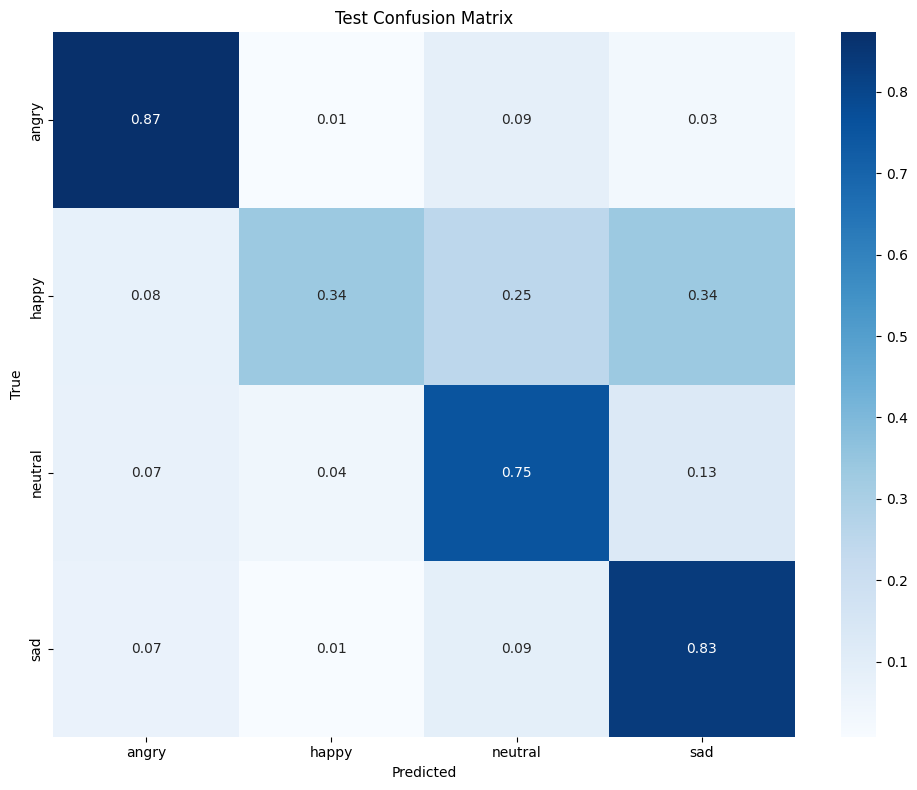

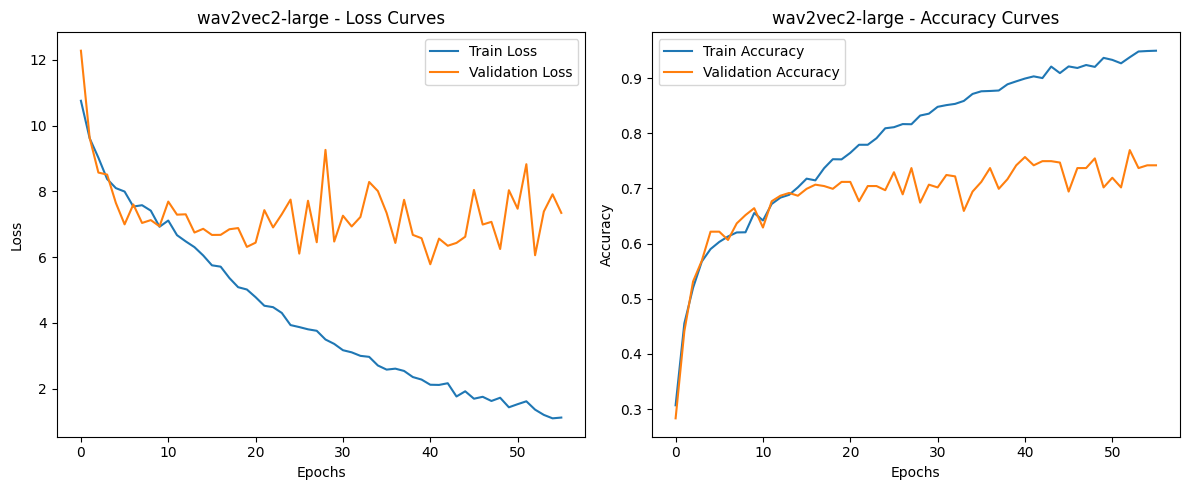


=== Results Summary ===
Model: wav2vec2-large
  Best validation accuracy: 0.7694
  Test accuracy: 0.7492
  Best validation loss: 5.7806
  Epochs trained: 56


In [137]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchaudio
from transformers import AutoModel, get_linear_schedule_with_warmup
import numpy as np
import matplotlib.pyplot as plt

# First install necessary packages
# !pip install transformers
# !pip install datasets
# !pip install torchaudio

def run_wav2vec2_experiment():

    # Modified configs list with just wav2vec2-large
    configs = [
        {
            'name': 'wav2vec2-large',
            'pretrained_model': 'facebook/wav2vec2-large',
            'unfreeze_layers': 4,
            'classifier_dropout': 0.1,
            'use_attention': True
        }
    ]

    results = {}

    # Get labelid and merge_map
    labelid, merge_map = create_label_mapping(dataset)

    # Define train/val/test split
    train_test = dataset['train'].train_test_split(test_size=0.2, seed=42)
    train_valid = train_test['train'].train_test_split(test_size=0.1, seed=42)

    train_dataset = Wav2Vec2Dataset(train_valid['train'], labelid, merge_map, is_training=True)
    val_dataset = Wav2Vec2Dataset(train_valid['test'], labelid, merge_map, is_training=False)
    test_dataset = Wav2Vec2Dataset(train_test['test'], labelid, merge_map, is_training=False)

    # Create dataloaders with proper collation
    def collate_fn(batch):
        # This handles variable length inputs by padding them
        waveforms = [item[0] for item in batch]
        labels = torch.tensor([item[1] for item in batch])

        # Pad waveforms to same length
        max_len = max(waveform.shape[1] for waveform in waveforms)
        padded_waveforms = []
        attention_masks = []

        for waveform in waveforms:
            padding = max_len - waveform.shape[1]
            if padding > 0:
                padded = F.pad(waveform, (0, padding))
                # Create attention mask (1 for actual values, 0 for padding)
                mask = torch.ones(waveform.shape[1], dtype=torch.long)
                mask = F.pad(mask, (0, padding), value=0)
            else:
                padded = waveform
                mask = torch.ones(waveform.shape[1], dtype=torch.long)

            padded_waveforms.append(padded)
            attention_masks.append(mask)

        waveforms_batch = torch.cat(padded_waveforms, dim=0)
        attention_masks_batch = torch.stack(attention_masks)

        return waveforms_batch, attention_masks_batch, labels

    train_dl = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)
    val_dl = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)
    test_dl = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)

    # Compute class weights for balanced loss
    class_sample_count = np.zeros(len(labelid))
    for _, label in train_dataset:
        class_sample_count[label] += 1
    weight = 1. / class_sample_count
    weight = torch.FloatTensor(weight / weight.sum())
    weight = weight.to(device)

    for config in configs:
        print(f"\n=== Testing {config['name']} ===")

        # Create model with this configuration
        model = Wav2Vec2WithStatPooling(num_classes, pretrained_model_name=config['pretrained_model'])
        model = model.to(device)

        # Initialize with same random seed for fair comparison
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(42)

        # Different parameter groups for different learning rates
        param_groups = [
            {'params': [p for n, p in model.wav2vec2.named_parameters() if p.requires_grad],
            'lr': 1e-5, 'weight_decay': 1e-8},  # Lower LR and WD for pretrained
            {'params': list(model.stat_pooling.parameters()) + list(model.classifier.parameters()),
            'lr': 3e-4, 'weight_decay': 1e-4}  # Higher LR for new layers
        ]

        # Optimizer with different learning rates
        optimizer = optim.AdamW(param_groups)

        # Learning rate scheduler with warmup
        total_steps = 100 * len(train_dl)  # 100 epochs max
        warmup_steps = int(0.1 * total_steps)
        # First scheduler (linear warmup)
        warmup_scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_steps
        )

        # Loss function with class weighting
        criterion = AdditiveMarginSoftmaxLoss(margin=0.3, scale=30.0)

        # Learning rate scheduler
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=0.5,  # Reduce LR by half when triggered
            patience=3,  # Wait 3 epochs without improvement before reducing LR
            min_lr=1e-6,  # Don't reduce LR below this threshold
            verbose=True  # Print message when LR is reduced
        )

        # Train with gradient accumulation and mixed precision
        history = train_wav2vec_model(
            model,
            train_dl,
            val_dl,
            optimizer,
            criterion,
            scheduler,
            warmup_scheduler=warmup_scheduler,
            epochs=100,
            patience=15,
            accumulation_steps=4  # Effective batch size of 32
        )

        # Evaluate on test set
        test_loss, test_acc = evaluate_model(model, test_dl, criterion)
        cm, cm_norm = plot_confusion_matrix(model, test_dl, labelid)

        # Save results
        results[config['name']] = {
            'best_val_acc': max(history['test_acc']),
            'final_val_acc': history['test_acc'][-1],
            'test_acc': test_acc,
            'best_val_loss': min(history['test_loss']),
            'test_loss': test_loss,
            'training_time': len(history['train_loss'])  # epochs trained before early stopping
        }

        # Save model weights
        torch.save(model.state_dict(), f"wav2vec2_{config['name'].replace('-', '_')}.pt")

        # Plot learning curves
        plot_learning_curves(history, config['name'])

    # Print comparison
    print("\n=== Results Summary ===")
    for config_name, metrics in results.items():
        print(f"Model: {config_name}")
        print(f"  Best validation accuracy: {metrics['best_val_acc']:.4f}")
        print(f"  Test accuracy: {metrics['test_acc']:.4f}")
        print(f"  Best validation loss: {metrics['best_val_loss']:.4f}")
        print(f"  Epochs trained: {metrics['training_time']}")

    return results

def train_wav2vec_model(model, train_dl, val_dl, optimizer, criterion, scheduler, warmup_scheduler,
                        epochs=100, patience=10, accumulation_steps=4):
    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': []
    }
    best_loss = float('inf')
    patience_counter = 0
    scaler = torch.cuda.amp.GradScaler()  # For mixed precision training

    for epoch in range(epochs):
        # Training
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        optimizer.zero_grad()

        for i, (waveforms, attention_masks, labels) in enumerate(train_dl):
            waveforms, attention_masks, labels = to_device(waveforms, device), to_device(attention_masks, device), to_device(labels, device)

            # Mixed precision forward pass
            with torch.cuda.amp.autocast():
                outputs = model(waveforms, attention_mask=attention_masks)
                loss = criterion(outputs, labels) / accumulation_steps

            # Scaled backward pass
            scaler.scale(loss).backward()

            # Update weights every accumulation_steps batches
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_dl):
                scaler.step(optimizer)
                scaler.update()
                warmup_scheduler.step()
                optimizer.zero_grad()

            # Track metrics
            total_loss += loss.item() * accumulation_steps
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_dl)
        train_acc = correct / total

        # Validation
        test_loss, test_acc = evaluate_model(model, val_dl, criterion)

        # Add this line to step the scheduler based on validation loss
        scheduler.step(test_loss)

        # Print progress
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

        # Update history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        # Early stopping
        if test_loss < best_loss:
            best_loss = test_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

    return history

def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for waveforms, attention_masks, labels in dataloader:
            waveforms, attention_masks, labels = to_device(waveforms, device), to_device(attention_masks, device), to_device(labels, device)

            outputs = model(waveforms, attention_mask=attention_masks)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(dataloader), correct / total

def plot_learning_curves(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['test_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'{model_name} - Loss Curves')

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['test_acc'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'{model_name} - Accuracy Curves')

    plt.tight_layout()
    plt.savefig(f"{model_name}_learning_curves.png")
    plt.show()

# Run the experiment
wav2vec2_results = run_wav2vec2_experiment()

### Start Training

In [58]:
# wandb.init(
#     project="emotion-recognition",  # your project name on wandb
#     config={
#         "epochs": 20,
#         "batch_size": 32,
#         "learning_rate": 1e-4,
#         "model": "ResNet-18",
#         "optimizer": "Adam"
#     }
# )


In [59]:
# from collections import Counter
# import torch
# from torch.utils.data import DataLoader
# import torch.nn as nn
# import torch.optim as optim

# # ============================================
# # 1. Label Mapping and Class Count
# # ============================================

# label2id, merge_map = create_label_mapping(train_dataset)
# num_classes = len(label2id)

# # Count class frequencies for weighting
# all_labels = []
# for item in train_dataset:
#     if item['major_emotion'] in merge_map:
#         merged = merge_map[item['major_emotion']]
#         all_labels.append(merged)

# label_counts = Counter(all_labels)
# emotion_order = sorted(set(merge_map.values()))
# counts = [label_counts[e] for e in emotion_order]
# weights = 1. / torch.tensor(counts, dtype=torch.float32)
# weights = weights.to(device)


# # ============================================
# # 2. Dataset and DataLoader
# # ============================================

# train_ds = CleanLogMelDataset(train_dataset, label2id, merge_map, is_training=True)
# val_ds   = CleanLogMelDataset(valid_dataset, label2id, merge_map, is_training=False)
# test_ds  = CleanLogMelDataset(test_dataset, label2id, merge_map, is_training=False)

# train_dl = DeviceDataLoader(DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=4, pin_memory=True), device)
# val_dl   = DeviceDataLoader(DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True), device)
# test_dl  = DeviceDataLoader(DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=4, pin_memory=True), device)

# ============================================
# 3. Model, Loss, Optimizer
# ============================================

# model = to_device(CRNNEmotion(num_classes), device)

# criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
# optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

# # ============================================
# # 4. Training
# # ============================================

# history = train_model(
#     model,
#     train_dl,
#     val_dl,
#     optimizer,
#     criterion,
#     epochs=300
# )


In [60]:
# def run_cnn_pattern_experiment():
#     # List of patterns to test
#     patterns = ['reducing', 'bottleneck', 'expansion', 'constant']
#     results = {}

#     for pattern in patterns:
#         print(f"\n=== Testing CNN pattern: {pattern} ===")

#         # Create model with this pattern
#         model = to_device(CNNAttentionEmotion(num_classes, cnn_pattern=pattern), device)

#         # Initialize with same random seed for fair comparison
#         torch.manual_seed(42)
#         if torch.cuda.is_available():
#             torch.cuda.manual_seed_all(42)

#         # Configure criterion and optimizer
#         criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
#         optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

#         # Train and evaluate
#         history = train_model(
#             model,
#             train_dl,
#             val_dl,
#             optimizer,
#             criterion,
#             epochs=100,  # Reduced epochs for faster experimentation
#             patience=10
#         )

#         # Save results
#         results[pattern] = {
#             'best_val_acc': max(history['test_acc']),
#             'final_val_acc': history['test_acc'][-1],
#             'best_val_loss': min(history['test_loss']),
#             'training_time': len(history['train_loss'])  # epochs trained before early stopping
#         }

#         # Optional: save model weights
#         torch.save(model.state_dict(), f'model_{pattern}.pt')

#     # Print comparison
#     print("\n=== Results Summary ===")
#     for pattern, metrics in results.items():
#         print(f"Pattern: {pattern}")
#         print(f"  Best validation accuracy: {metrics['best_val_acc']:.4f}")
#         print(f"  Best validation loss: {metrics['best_val_loss']:.4f}")
#         print(f"  Epochs trained: {metrics['training_time']}")

#     return results

# # Run the experiment
# results = run_cnn_pattern_experiment()


=== Testing CNN pattern: reducing ===
Epoch [1/100], Train Loss: 1.2701, Train Acc: 0.4291, Test Loss: 1.3098, Test Acc: 0.4461
Epoch [2/100], Train Loss: 1.2220, Train Acc: 0.4624, Test Loss: 1.2316, Test Acc: 0.4436
Epoch [3/100], Train Loss: 1.1974, Train Acc: 0.4900, Test Loss: 1.1804, Test Acc: 0.4912
Epoch [4/100], Train Loss: 1.1854, Train Acc: 0.5089, Test Loss: 1.1776, Test Acc: 0.4937
Epoch [5/100], Train Loss: 1.1821, Train Acc: 0.5044, Test Loss: 1.1828, Test Acc: 0.5539
Epoch [6/100], Train Loss: 1.1724, Train Acc: 0.5179, Test Loss: 1.1567, Test Acc: 0.5739
Epoch [7/100], Train Loss: 1.1697, Train Acc: 0.5235, Test Loss: 1.1785, Test Acc: 0.5213
Epoch [8/100], Train Loss: 1.1620, Train Acc: 0.5249, Test Loss: 1.1813, Test Acc: 0.5789
Epoch [9/100], Train Loss: 1.1544, Train Acc: 0.5382, Test Loss: 1.1418, Test Acc: 0.5514
Epoch [10/100], Train Loss: 1.1540, Train Acc: 0.5416, Test Loss: 1.1157, Test Acc: 0.5689
Epoch [11/100], Train Loss: 1.1480, Train Acc: 0.5404, Test 

In [61]:
# def run_transformer_experiment():
#     # Create configurations to test
#     configs = [
#         {'name': 'small', 'nhead': 4, 'num_encoder_layers': 2, 'd_model': 128},
#         {'name': 'medium', 'nhead': 8, 'num_encoder_layers': 3, 'd_model': 256},
#         {'name': 'large', 'nhead': 16, 'num_encoder_layers': 4, 'd_model': 512}
#     ]

#     results = {}

#     for config in configs:
#         print(f"\n=== Testing Transformer config: {config['name']} ===")

#         # Create model with this configuration
#         # Create model with this configuration
#         model = to_device(TransformerSERModel(
#             num_classes=num_classes,
#             nhead=config['nhead'],
#             num_encoder_layers=config['num_encoder_layers'],
#             d_model=config['d_model']
#         ), device)

#         # Initialize with same random seed for fair comparison
#         torch.manual_seed(42)
#         if torch.cuda.is_available():
#             torch.cuda.manual_seed_all(42)

#         # Configure criterion and optimizer
#         criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
#         optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)

#         # Train and evaluate
#         history = train_model(
#             model,
#             train_dl,
#             val_dl,
#             optimizer,
#             criterion,
#             epochs=100,
#             patience=10
#         )

#         # Save results
#         results[config['name']] = {
#             'best_val_acc': max(history['test_acc']),
#             'final_val_acc': history['test_acc'][-1],
#             'best_val_loss': min(history['test_loss']),
#             'training_time': len(history['train_loss'])
#         }

#         # Save model weights
#         torch.save(model.state_dict(), f'transformer_{config["name"]}.pt')

#     # Print comparison
#     print("\n=== Results Summary ===")
#     for config_name, metrics in results.items():
#         print(f"Config: {config_name}")
#         print(f"  Best validation accuracy: {metrics['best_val_acc']:.4f}")
#         print(f"  Best validation loss: {metrics['best_val_loss']:.4f}")
#         print(f"  Epochs trained: {metrics['training_time']}")

#     return results

# # Import math for positional encoding
# import math

# # Run the experiment
# transformer_results = run_transformer_experiment()


=== Testing Transformer config: small ===
Epoch [1/100], Train Loss: 1.3006, Train Acc: 0.3998, Test Loss: 1.3156, Test Acc: 0.4511
Epoch [2/100], Train Loss: 1.2197, Train Acc: 0.4737, Test Loss: 1.2170, Test Acc: 0.4812
Epoch [3/100], Train Loss: 1.1978, Train Acc: 0.4846, Test Loss: 1.1651, Test Acc: 0.5163
Epoch [4/100], Train Loss: 1.1927, Train Acc: 0.5061, Test Loss: 1.1624, Test Acc: 0.5564
Epoch [5/100], Train Loss: 1.1864, Train Acc: 0.5080, Test Loss: 1.1824, Test Acc: 0.5564
Epoch [6/100], Train Loss: 1.1847, Train Acc: 0.5142, Test Loss: 1.1575, Test Acc: 0.5614
Epoch [7/100], Train Loss: 1.1714, Train Acc: 0.5249, Test Loss: 1.2130, Test Acc: 0.5388
Epoch [8/100], Train Loss: 1.1673, Train Acc: 0.5258, Test Loss: 1.1772, Test Acc: 0.5639
Epoch [9/100], Train Loss: 1.1621, Train Acc: 0.5317, Test Loss: 1.1328, Test Acc: 0.5664
Epoch [10/100], Train Loss: 1.1654, Train Acc: 0.5272, Test Loss: 1.1359, Test Acc: 0.5789
Epoch [11/100], Train Loss: 1.1556, Train Acc: 0.5418, T

In [64]:
# def run_vit_experiment():
#     # Create configurations to test (small, medium, large)
#     configs = [
#         {
#             'name': 'tiny',
#             'patch_size': 8,
#             'dim': 192,
#             'depth': 4,
#             'heads': 3,
#             'mlp_dim': 384
#         },
#         {
#             'name': 'small',
#             'patch_size': 8,
#             'dim': 256,
#             'depth': 6,
#             'heads': 4,
#             'mlp_dim': 512
#         },
#         {
#             'name': 'medium',
#             'patch_size': 8,
#             'dim': 384,
#             'depth': 8,
#             'heads': 6,
#             'mlp_dim': 768
#         }
#     ]

#     results = {}

#     for config in configs:
#         print(f"\n=== Testing ViT config: {config['name']} ===")

#         # Create model with this configuration
#         # Create model with this configuration
#         model = to_device(ViTForSER(
#             num_classes=num_classes,
#             in_channels=1,  # For spectrograms
#             dim=config['dim'],
#             depth=config['depth'],
#             heads=config['heads'],
#             mlp_dim=config['mlp_dim']
#         ), device)

#         # Initialize with same random seed for fair comparison
#         torch.manual_seed(42)
#         if torch.cuda.is_available():
#             torch.cuda.manual_seed_all(42)

#         # Configure criterion and optimizer
#         criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)
#         optimizer = optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)  # Lower learning rate for ViT

#         # Train and evaluate
#         history = train_model(
#             model,
#             train_dl,
#             val_dl,
#             optimizer,
#             criterion,
#             epochs=100,
#             patience=10
#         )

#         # Save results
#         results[config['name']] = {
#             'best_val_acc': max(history['test_acc']),
#             'final_val_acc': history['test_acc'][-1],
#             'best_val_loss': min(history['test_loss']),
#             'training_time': len(history['train_loss'])
#         }

#         # Save model weights
#         torch.save(model.state_dict(), f'vit_{config["name"]}.pt')

#     # Print comparison
#     print("\n=== Results Summary ===")
#     for config_name, metrics in results.items():
#         print(f"Config: {config_name}")
#         print(f"  Best validation accuracy: {metrics['best_val_acc']:.4f}")
#         print(f"  Best validation loss: {metrics['best_val_loss']:.4f}")
#         print(f"  Epochs trained: {metrics['training_time']}")

#     return results

# # Run the experiment
# vit_results = run_vit_experiment()


=== Testing ViT config: tiny ===
Epoch [1/100], Train Loss: 1.4209, Train Acc: 0.2513, Test Loss: 1.3703, Test Acc: 0.2882
Epoch [2/100], Train Loss: 1.3559, Train Acc: 0.3429, Test Loss: 1.2889, Test Acc: 0.3409
Epoch [3/100], Train Loss: 1.2810, Train Acc: 0.4201, Test Loss: 1.2290, Test Acc: 0.4486
Epoch [4/100], Train Loss: 1.2532, Train Acc: 0.4491, Test Loss: 1.1961, Test Acc: 0.4662
Epoch [5/100], Train Loss: 1.2303, Train Acc: 0.4666, Test Loss: 1.2314, Test Acc: 0.5088
Epoch [6/100], Train Loss: 1.2185, Train Acc: 0.4737, Test Loss: 1.1984, Test Acc: 0.5288
Epoch [7/100], Train Loss: 1.2117, Train Acc: 0.4928, Test Loss: 1.1933, Test Acc: 0.4712
Epoch [8/100], Train Loss: 1.2022, Train Acc: 0.4818, Test Loss: 1.2071, Test Acc: 0.5363
Epoch [9/100], Train Loss: 1.2006, Train Acc: 0.4951, Test Loss: 1.1740, Test Acc: 0.4937
Epoch [10/100], Train Loss: 1.2030, Train Acc: 0.4849, Test Loss: 1.1650, Test Acc: 0.5363
Epoch [11/100], Train Loss: 1.1980, Train Acc: 0.5055, Test Loss:

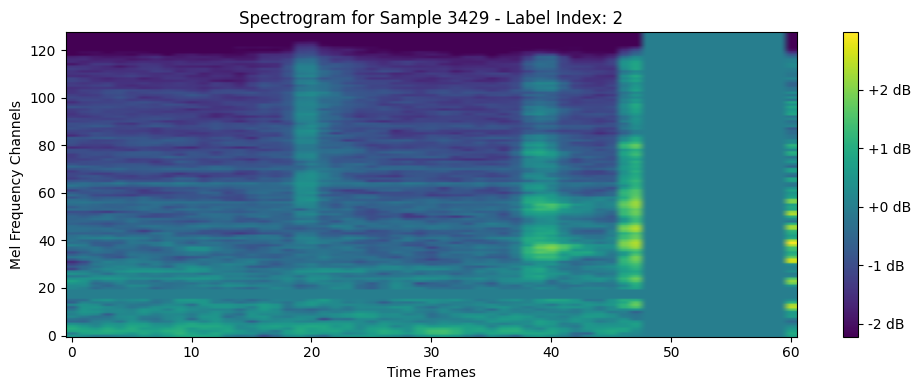

In [97]:
### Visualizing the spectogram
# Select a random sample
sample_idx = random.randint(0, len(train_ds)-1)
mel_spec, label = train_ds[sample_idx]

# Convert to numpy and reverse normalization for better visualization
mel_spec_np = mel_spec.squeeze().numpy()  # shape: (n_mels, time)

plt.figure(figsize=(10, 4))
plt.imshow(mel_spec_np, origin='lower', aspect='auto', cmap='viridis')
plt.colorbar(format="%+2.0f dB")
plt.title(f"Spectrogram for Sample {sample_idx} - Label Index: {label}")
plt.xlabel("Time Frames")
plt.ylabel("Mel Frequency Channels")
plt.tight_layout()
plt.show()

###  Visualizing the results